In [2]:
import os
os.chdir('../../../../..')

In [3]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pyriemann.tangentspace import TangentSpace
import umap
import seaborn as sns
from loguru import logger
from sklearn.manifold import TSNE, MDS

from src.datasets import QM9Dataset
from src.non_euclidean import Riemann, Grassmann
from src.helper_functions import create_chemiscope_viewer


In [4]:
qm9 = QM9Dataset(limit=80_000, descriptors=["soap"])
df = qm9.load()

2026-05-29 08:42:41.290 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-29 08:42:41.771 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=80000, returned_rows=80000, sampling on columns=['num_atoms', 'gap'].
2026-05-29 08:42:41.773 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=80000).
2026-05-29 08:42:41.856 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-29 08:47:21.237 | SUCCESS  | src.datasets:add_soap:1193 - Added SOAP embeddings and matrices.
2026-05-29 08:47:21.327 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-05-29 08:47:21.504 | INFO     | src.datasets:_load_with_descriptor_filter:857 - QM9 descriptor null-filtering 

In [5]:
from dscribe.kernels import REMatchKernel

def rematch_kernel_dist_matrix(df, metric="linear", alpha=0.1, tol=1e-3):

    soap_matrices = df["soap_matrix"].to_list()

    cleaned = []

    normalized = False
    for i, x in enumerate(soap_matrices):
        x = np.asarray(x, dtype=np.float64)

        # shape check
        if x.ndim != 2:
            raise ValueError(f"SOAP matrix {i} is not 2D: shape={x.shape}")

        # finite check
        if not np.isfinite(x).all():
            raise ValueError(f"Non-finite values in SOAP matrix {i}")

        # ----------------------------
        # Check if already normalized
        # ----------------------------
        norms = np.linalg.norm(x, axis=1)

        already_normalized = np.all(np.abs(norms - 1.0) < tol)

        if already_normalized:
            x_norm = x
            normalized = True
            cleaned = soap_matrices
            logger.info("Descriptor is already normalized")
            if normalized:
                break
        else:
            x_norm = x / (norms[:, None] + 1e-12)
        

        # final sanity check
        if not np.isfinite(x_norm).all():
            raise ValueError(f"NaN/inf after normalization in matrix {i}")

        cleaned.append(x_norm)

    # ----------------------------
    # REMatch kernel
    # ----------------------------
    kernel = REMatchKernel(
        metric=metric,
        alpha=alpha
    )

    print("Computing REMatch kernel matrix...")
    K = kernel.create(cleaned)

    if not np.isfinite(K).all():
        raise ValueError("Kernel matrix contains NaN or inf")

    # ----------------------------
    # Distance conversion
    # ----------------------------
    diag = np.diag(K)
    dist_sq = diag[:, None] + diag[None, :] - 2.0 * K

    dist_sq = np.clip(dist_sq, 0.0, None)
    D = np.sqrt(dist_sq)

    np.fill_diagonal(D, 0.0)
    D = (D + D.T) / 2.0

    return D

# Hypothesis 1
- an experiment showing the time benefit of grassmann compared to riemann and rematch kernel

In [ ]:
import time
import pandas as pd
from sklearn.covariance import oas
from scipy.spatial.distance import pdist, squareform

# =============================================================================
# OPTIMIZED GEOMETRIC FRAMEWORKS
# =============================================================================

class GrassmannProfiler:
    """
    Optimized Grassmannian framework locked strictly to the right singular vectors
    to guarantee shape invariance across molecules with varying atom counts.
    """
    @classmethod
    def compute_descriptors(cls, raw_matrices: list, k: int = 3) -> list:
        bases = []
        for X in raw_matrices:
            _, _, vh = np.linalg.svd(X, full_matrices=False)
            bases.append(vh.T[:, :k])
        return bases

    @classmethod
    def compute_distances(cls, bases: list) -> np.ndarray:
        num_items = len(bases)
        dist_matrix = np.zeros((num_items, num_items))
        bases_T = [U.T for U in bases]
        
        for i in range(num_items):
            U1_T = bases_T[i]
            for j in range(i + 1, num_items):
                core_matrix = U1_T @ bases[j]
                s = np.linalg.svd(core_matrix, compute_uv=False)
                angles = np.arccos(np.clip(s, 0.0, 1.0))
                d = float(np.linalg.norm(angles))  # Geodesic distance
                dist_matrix[i, j] = dist_matrix[j, i] = d
        return dist_matrix


class RiemannProfiler:
    """Handles Log-Euclidean Tangent Space representation profiling."""
    @classmethod
    def compute_descriptors(cls, raw_matrices: list) -> np.ndarray:
        vectorized_dataset = []
        for X in raw_matrices:
            X_centered = X - np.mean(X, axis=0)
            C, _ = oas(X_centered, assume_centered=True)
            
            eigenvalues, eigenvectors = np.linalg.eigh(C)
            eigenvalues = np.clip(eigenvalues, a_min=1e-12, a_max=None)
            log_C = eigenvectors @ np.diag(np.log(eigenvalues)) @ eigenvectors.T
            
            d = log_C.shape[0]
            triu_idx = np.triu_indices(d)
            weight_matrix = np.where(np.eye(d, dtype=bool), 1.0, np.sqrt(2.0))
            weighted_log_C = log_C * weight_matrix
            vectorized_dataset.append(weighted_log_C[triu_idx])
            
        return np.array(vectorized_dataset)

    @classmethod
    def compute_distances(cls, X_tangent: np.ndarray) -> np.ndarray:
        return squareform(pdist(X_tangent, metric="euclidean"))


class REMatchProfiler:
    """Authentic profiling wrapper utilizing the true dscribe REMatchKernel engine."""
    @classmethod
    def compute_distances(cls, raw_matrices: list, metric="linear", alpha=0.1, tol=1e-3) -> np.ndarray:
        cleaned = []
        for i, x in enumerate(raw_matrices):
            x = np.asarray(x, dtype=np.float64)
            if x.ndim != 2:
                raise ValueError(f"SOAP matrix {i} is not 2D: shape={x.shape}")
            if not np.isfinite(x).all():
                raise ValueError(f"Non-finite values in SOAP matrix {i}")

            # Safe normalization sequence matching your production pipeline
            norms = np.linalg.norm(x, axis=1)
            x_norm = x if np.all(np.abs(norms - 1.0) < tol) else x / (norms[:, None] + 1e-12)
            cleaned.append(x_norm)

        # Call authentic DScribe backend setup
        kernel = REMatchKernel(metric=metric, alpha=alpha)
        K = kernel.create(cleaned)

        if not np.isfinite(K).all():
            raise ValueError("Kernel matrix contains NaN or inf")

        # Convert kernel coordinates to Euclidean distance space
        diag = np.diag(K)
        dist_sq = diag[:, None] + diag[None, :] - 2.0 * K
        dist_sq = np.clip(dist_sq, 0.0, None)
        D = np.sqrt(dist_sq)

        np.fill_diagonal(D, 0.0)
        return (D + D.T) / 2.0

# =============================================================================
# BENCHMARK ENGINE
# =============================================================================

def run_scaling_frontier_experiment():
    # Experimental dimensions
    M_molecules = 60        # Safe baseline for full REMatch kernel cross-computation
    N_atoms = 24            # Target atoms per molecule
    D_dimensions = [64, 128, 256, 512, 1024, 2048]  # Full resolution sweep
    k_grassmann = 4         # Fixed subspace rank
    
    results = []

    print(f"Starting Benchmark | Configuration: M={M_molecules} Molecules, N={N_atoms} Atoms")
    print("=" * 90)

    for D in D_dimensions:
        print(f"Evaluating Feature Dimensionality: D = {D}...")
        
        # Generate clean synthetic representation arrays matching the feature size step
        np.random.seed(42)
        raw_data = [np.random.randn(N_atoms, D) for _ in range(M_molecules)]
        
        # ---------------------------------------------------------------------
        # 1. PROFILE AUTHENTIC REMATCH BASELINE
        # ---------------------------------------------------------------------
        t0 = time.perf_counter()
        _ = REMatchProfiler.compute_distances(raw_data)
        t_rematch = time.perf_counter() - t0
        mem_rematch = sum(X.nbytes for X in raw_data) / (1024**2) 

        # ---------------------------------------------------------------------
        # 2. PROFILE RIEMANN MANIFOLD
        # ---------------------------------------------------------------------
        t0 = time.perf_counter()
        X_tangent = RiemannProfiler.compute_descriptors(raw_data)
        _ = RiemannProfiler.compute_distances(X_tangent)
        t_riemann = time.perf_counter() - t0
        mem_riemann = X_tangent.nbytes / (1024**2)

        # ---------------------------------------------------------------------
        # 3. PROFILE GRASSMANNIAN MANIFOLD
        # ---------------------------------------------------------------------
        t0 = time.perf_counter()
        bases = GrassmannProfiler.compute_descriptors(raw_data, k=k_grassmann)
        _ = GrassmannProfiler.compute_distances(bases)
        t_grassmann = time.perf_counter() - t0
        mem_grassmann = sum(B.nbytes for B in bases) / (1024**2)

        results.append({
            "D": D,
            "Time REMatch (s)": t_rematch,
            "Mem REMatch (MB)": mem_rematch,
            "Time Riemann (s)": t_riemann,
            "Mem Riemann (MB)": mem_riemann,
            "Time Grassmann (s)": t_grassmann,
            "Mem Grassmann (MB)": mem_grassmann
        })

    # Compile into formatting dataframe
    df_results = pd.DataFrame(results)
    
    print("\n" + "="*90)
    print(" FINAL EXPERIMENTAL PERFORMANCE SUMMARY")
    print("="*90)
    print(df_results.to_markdown(index=False, floatfmt=".4f"))
    print("="*90)


In [24]:
run_scaling_frontier_experiment()

Starting Benchmark | Configuration: M=60 Molecules, N=24 Atoms
Evaluating Feature Dimensionality: D = 64...
Evaluating Feature Dimensionality: D = 128...
Evaluating Feature Dimensionality: D = 256...
Evaluating Feature Dimensionality: D = 512...
Evaluating Feature Dimensionality: D = 1024...
Evaluating Feature Dimensionality: D = 2048...

 FINAL EXPERIMENTAL PERFORMANCE SUMMARY
|         D |   Time REMatch (s) |   Mem REMatch (MB) |   Time Riemann (s) |   Mem Riemann (MB) |   Time Grassmann (s) |   Mem Grassmann (MB) |
|----------:|-------------------:|-------------------:|-------------------:|-------------------:|---------------------:|---------------------:|
|   64.0000 |             0.2141 |             0.7031 |             0.0388 |             0.9521 |               0.0226 |               0.1172 |
|  128.0000 |             0.1841 |             1.4062 |             0.1060 |             3.7793 |               0.0269 |               0.2344 |
|  256.0000 |             0.1858 |         

# Hypothesis 2
- grassmann will be resisient to noise in the coordinates

In [19]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from ase import Atoms
from dscribe.descriptors import SOAP

# =============================================================================
# MAIN EXPERIMENT
# =============================================================================
def run_robustness_benchmark(
    df_base: pl.DataFrame,
    n_parent_mols: int = 6,
    n_perturbations: int = 20,
    k_grassmann_list=[2, 3, 5]
):

    # 1. SAMPLE MOLECULES & SETUP SOAP
    df_parents = df_base.sample(n_parent_mols, seed=42)

    flat_atomic_numbers = [
        num for sublist in df_parents["atomic_numbers"].to_list() for num in sublist
    ]
    species = sorted(list(set(flat_atomic_numbers)))

    soap = SOAP(
        species=species,
        r_cut=5.0,
        n_max=4,
        l_max=3,
        periodic=False,
        sparse=False
    )

    # Expanded sigma levels for higher resolution curves
    sigma_levels = [0.00, 0.01, 0.03, 0.05, 0.075, 0.10, 0.15, 0.20, 0.25]
    
    frameworks = ["REMatch", "Riemann"] + [f"Grassmann (k={k})" for k in k_grassmann_list]

    metrics = {
        fw: {
            "drift": [],
            "retrieval_acc": []
        }
        for fw in frameworks
    }
    
    # Track the actual physical movement of the atoms in Ångströms
    physical_displacements = []

    print("Running robustness benchmark (Physical Deformation, Drift & Retrieval)...")

    # 2. PRECOMPUTE CLEAN REFERENCES
    clean_records = []
    for i, row in enumerate(df_parents.iter_rows(named=True)):
        nums = row["atomic_numbers"]
        coords = np.array(row["coordinates"], dtype=np.float64)
        clean_soap = soap.create(Atoms(numbers=nums, positions=coords)).tolist()
        
        clean_records.append({
            "parent_idx": i,
            "is_clean": True,
            "soap_matrix": clean_soap,
            "coords": coords,
            "nums": nums
        })

    # 3. MAIN LOOP OVER NOISE LEVELS
    for sigma in sigma_levels:
        print(f"Evaluating Sigma = {sigma}")

        all_records = list(clean_records) 
        current_sigma_displacements = []
        
        if sigma > 0.0:
            for clean in clean_records:
                for _ in range(n_perturbations):
                    noise = np.random.normal(0, sigma, clean["coords"].shape)
                    
                    # Calculate actual physical distance each atom moved
                    atom_distances = np.linalg.norm(noise, axis=1)
                    current_sigma_displacements.extend(atom_distances)
                    
                    pert = Atoms(numbers=clean["nums"], positions=clean["coords"] + noise)
                    noisy_soap = soap.create(pert).tolist()
                    
                    all_records.append({
                        "parent_idx": clean["parent_idx"],
                        "is_clean": False,
                        "soap_matrix": noisy_soap,
                        "coords": None, 
                        "nums": None
                    })
            
            # Average physical displacement for this noise level
            physical_displacements.append(np.mean(current_sigma_displacements))
        else:
            physical_displacements.append(0.0)

        # Build Polars DataFrame natively 
        df = pl.DataFrame(all_records)
        
        # Identify indices
        idx_clean = df.with_row_index().filter(pl.col("is_clean")).select("index").to_series().to_list()
        idx_noisy = df.with_row_index().filter(~pl.col("is_clean")).select("index").to_series().to_list()

        # 4. DISTANCE MATRICES
        matrices = {}
        
        matrices["REMatch"] = rematch_kernel_dist_matrix(df)
        matrices["Riemann"] = Riemann().distance_matrix(df, "soap", distance_type="log-euclidean")
        
        for k in k_grassmann_list:
            matrices[f"Grassmann (k={k})"] = Grassmann().distance_matrix(df, "soap", distance_type="geodesic", k=k)

        # Store baseline 
        if sigma == 0.0:
            for fw in frameworks:
                metrics[fw]["drift"].append(0.0)
                metrics[fw]["retrieval_acc"].append(1.0)
            continue

        # 5. CALCULATE METRICS
        for name, M in matrices.items():
            
            # --- Retrieval Accuracy ---
            correct_retrievals = 0
            drift_vals = []
            
            for noisy_i in idx_noisy:
                true_parent = df["parent_idx"][noisy_i]
                
                # Slicing the row of the noisy molecule, focusing only on columns of clean molecules
                distances_to_cleans = M[noisy_i, idx_clean]
                
                # The index in `distances_to_cleans` matches the parent index
                predicted_parent = np.argmin(distances_to_cleans)
                
                if predicted_parent == true_parent:
                    correct_retrievals += 1
                    
                # Track drift: distance from this noisy instance to its SPECIFIC true clean parent
                drift_vals.append(distances_to_cleans[true_parent])

            retrieval_acc = correct_retrievals / len(idx_noisy)
            
            # --- Store ---
            metrics[name]["drift"].append(np.mean(drift_vals))
            metrics[name]["retrieval_acc"].append(retrieval_acc)

    # =============================================================================
    # PLOTS
    # =============================================================================
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

    # Automatically generate colors for the Grassmann variants
    cmap = plt.cm.get_cmap("Blues")
    grassmann_colors = [cmap(0.5 + 0.5 * (i / len(k_grassmann_list))) for i in range(len(k_grassmann_list))]
    
    colors = {
        "REMatch": "gray", 
        "Riemann": "red"
    }
    for i, k in enumerate(k_grassmann_list):
        colors[f"Grassmann (k={k})"] = grassmann_colors[i]

    # # Plot 1: Physical Deformation (New)
    # ax[0].plot(sigma_levels, physical_displacements, color="black", marker="s", linestyle="--")
    # ax[0].set_title("Actual Physical Deformation")
    # ax[0].set_xlabel("Gaussian Noise σ")
    # ax[0].set_ylabel("Mean Atomic Displacement (Å)")

    # Plot 2: Drift (Distance from Parent)
    for fw in frameworks:
        ax[0].plot(sigma_levels, metrics[fw]["drift"], label=fw, color=colors[fw], marker="o")
    ax[0].set_title("Manifold Drift from Clean Parent")
    ax[0].set_xlabel("Gaussian Noise σ")
    ax[0].set_ylabel("Absolute Distance in Manifold")

    # Plot 3: Retrieval Accuracy
    for fw in frameworks:
        ax[1].plot(sigma_levels, metrics[fw]["retrieval_acc"], label=fw, color=colors[fw], marker="o")
    ax[1].set_title("Parent Retrieval Accuracy")
    ax[1].set_xlabel("Gaussian Noise σ")
    ax[1].set_ylabel("Fraction Correctly Classified")
    ax[1].set_ylim([0.8, 1.05])

    for a in ax[0:]:
        a.legend()
        
    for a in ax:
        a.grid(True, linestyle=":")

    plt.tight_layout()
    plt.show()

2026-05-29 09:07:20.485 | INFO     | src.non_euclidean:distance_matrix:1108 - Computing Riemann distance matrix | Features: soap | Distance: log-euclidean
2026-05-29 09:07:20.485 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df


Running robustness benchmark (Physical Deformation, Drift & Retrieval)...
Evaluating Sigma = 0.0
Computing REMatch kernel matrix...


2026-05-29 09:07:20.875 | INFO     | src.non_euclidean:distance_matrix:1118 - Computing log-euclidean distances...
2026-05-29 09:07:21.080 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:07:21.086 | INFO     | src.non_euclidean:distance_matrix:988 - Computing Grassmann distance matrix | Features: soap | Distance: geodesic | k: 2
Grassmann distances: 100%|██████████| 10/10 [00:00<00:00, 13756.33row/s]
2026-05-29 09:07:21.089 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:07:21.096 | INFO     | src.non_euclidean:distance_matrix:988 - Computing Grassmann distance matrix | Features: soap | Distance: geodesic | k: 3
Grassmann distances: 100%|██████████| 10/10 [00:00<00:00, 12941.39row/s]
2026-05-29 09:07:21.098 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:07:21.105 | INFO     | src.non_euclidean:dista

Evaluating Sigma = 0.01
Computing REMatch kernel matrix...


2026-05-29 09:07:24.132 | INFO     | src.non_euclidean:distance_matrix:1108 - Computing Riemann distance matrix | Features: soap | Distance: log-euclidean
2026-05-29 09:07:24.132 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:07:30.815 | INFO     | src.non_euclidean:distance_matrix:1118 - Computing log-euclidean distances...
2026-05-29 09:07:35.715 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:07:35.877 | INFO     | src.non_euclidean:distance_matrix:988 - Computing Grassmann distance matrix | Features: soap | Distance: geodesic | k: 2
Grassmann distances: 100%|██████████| 210/210 [00:00<00:00, 745.33row/s]
2026-05-29 09:07:36.165 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:07:36.283 | INFO     | src.non_euclidean:distance_matrix:988 - Computing Grassmann distance matrix | Features: soap | Dist

...

2026-05-29 09:08:38.542 | INFO     | src.non_euclidean:distance_matrix:1108 - Computing Riemann distance matrix | Features: soap | Distance: log-euclidean
2026-05-29 09:08:38.543 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:08:45.168 | INFO     | src.non_euclidean:distance_matrix:1118 - Computing log-euclidean distances...
2026-05-29 09:08:49.264 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:08:49.384 | INFO     | src.non_euclidean:distance_matrix:988 - Computing Grassmann distance matrix | Features: soap | Distance: geodesic | k: 2
Grassmann distances: 100%|██████████| 210/210 [00:00<00:00, 857.30row/s]
2026-05-29 09:08:49.631 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:08:49.750 | INFO     | src.non_euclidean:distance_matrix:988 - Computing Grassmann distance matrix | Features: soap | Dist

Evaluating Sigma = 0.2
Computing REMatch kernel matrix...


2026-05-29 09:08:53.380 | INFO     | src.non_euclidean:distance_matrix:1108 - Computing Riemann distance matrix | Features: soap | Distance: log-euclidean
2026-05-29 09:08:53.381 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:08:59.652 | INFO     | src.non_euclidean:distance_matrix:1118 - Computing log-euclidean distances...
2026-05-29 09:09:03.995 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:09:04.148 | INFO     | src.non_euclidean:distance_matrix:988 - Computing Grassmann distance matrix | Features: soap | Distance: geodesic | k: 2
Grassmann distances: 100%|██████████| 210/210 [00:00<00:00, 884.05row/s]
2026-05-29 09:09:04.392 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:09:04.508 | INFO     | src.non_euclidean:distance_matrix:988 - Computing Grassmann distance matrix | Features: soap | Dist

Evaluating Sigma = 0.25
Computing REMatch kernel matrix...


2026-05-29 09:09:08.374 | INFO     | src.non_euclidean:distance_matrix:1108 - Computing Riemann distance matrix | Features: soap | Distance: log-euclidean
2026-05-29 09:09:08.375 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:09:14.669 | INFO     | src.non_euclidean:distance_matrix:1118 - Computing log-euclidean distances...
2026-05-29 09:09:18.892 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:09:19.022 | INFO     | src.non_euclidean:distance_matrix:988 - Computing Grassmann distance matrix | Features: soap | Distance: geodesic | k: 2
Grassmann distances: 100%|██████████| 210/210 [00:00<00:00, 844.06row/s]
2026-05-29 09:09:19.274 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-29 09:09:19.391 | INFO     | src.non_euclidean:distance_matrix:988 - Computing Grassmann distance matrix | Features: soap | Dist

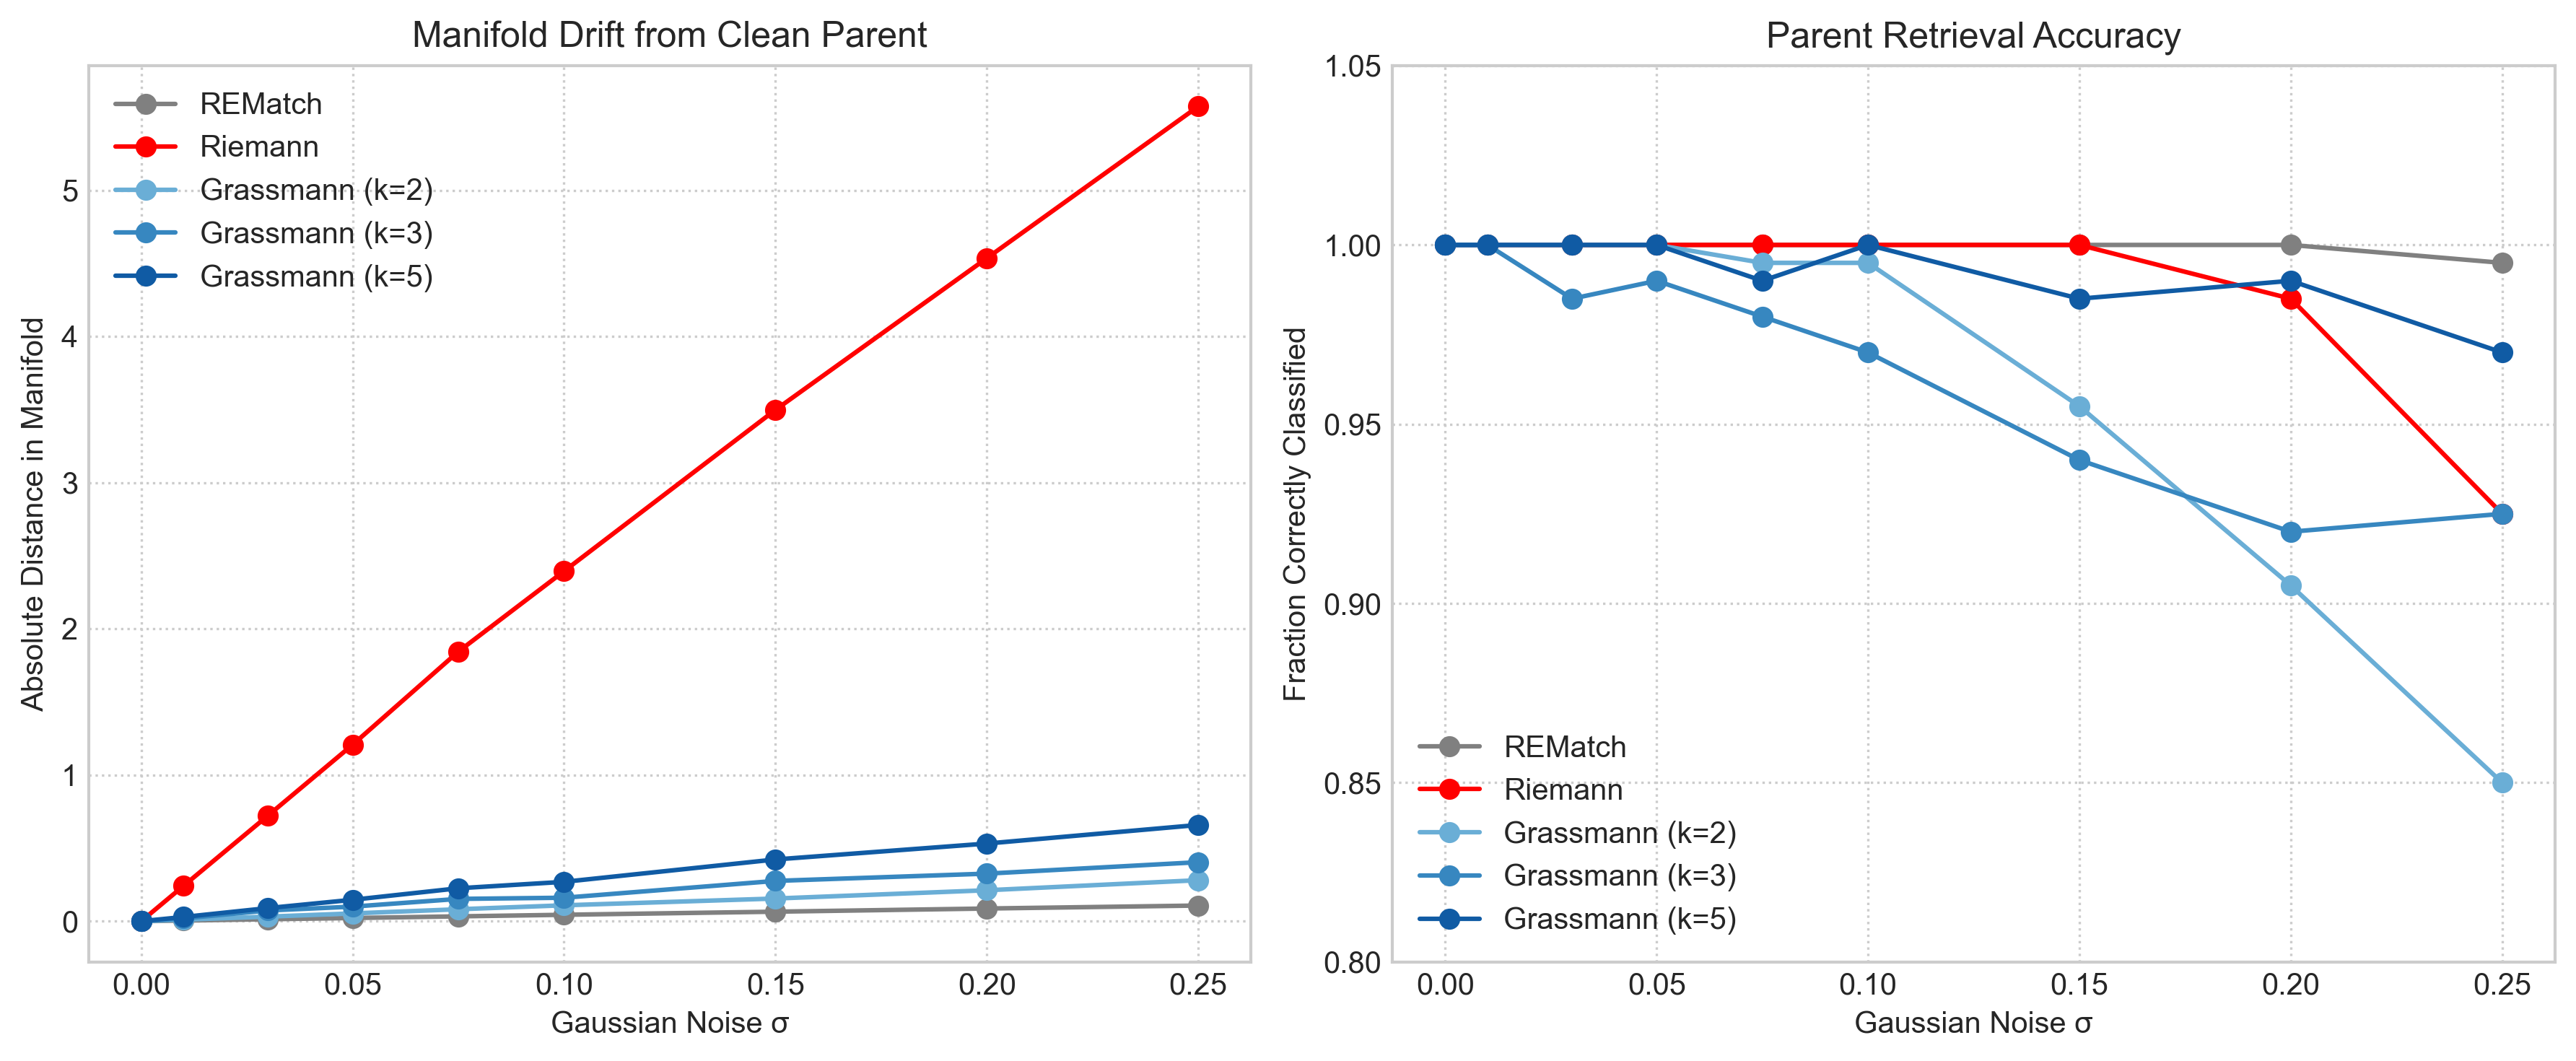

In [20]:
run_robustness_benchmark(df, n_parent_mols=10)

# Hypothesis 3

In [36]:
qm9 = QM9Dataset(limit=1000, descriptors=["soap"])
df_sample = qm9.load()

2026-05-26 14:55:21.162 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-26 14:55:21.560 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=1000, returned_rows=1000, sampling on columns=['num_atoms', 'gap'].
2026-05-26 14:55:21.561 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=1000).
2026-05-26 14:55:21.563 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-26 14:55:22.212 | SUCCESS  | src.datasets:add_soap:1193 - Added SOAP embeddings and matrices.
2026-05-26 14:55:22.212 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-05-26 14:55:22.215 | INFO     | src.datasets:_load_with_descriptor_filter:857 - QM9 descriptor null-filtering com

In [ ]:
import numpy as np
import polars as pl
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import KFold, cross_val_score

dist_matrix = Grassmann.distance_matrix(
    df=df_sample, 
    descriptor="soap", 
    distance_type="geodesic", 
    k=3
)

median_dist = np.median(dist_matrix[np.triu_indices_from(dist_matrix, k=1)])
gamma = 1.0 / (2.0 * (median_dist ** 2) + 1e-8)
kernel_matrix = np.exp(-gamma * (dist_matrix ** 2))

kr_model = KernelRidge(alpha=1.0, kernel="precomputed")
cv = KFold(n_splits=5, shuffle=True, random_state=42)

y = df_sample["cv"].to_numpy()

scores = cross_val_score(kr_model, kernel_matrix, y, cv=cv, scoring="neg_mean_absolute_error")
print(f"Grassmann Kernel Ridge MAE: {-np.mean(scores):.4f}")

2026-05-26 14:55:30.727 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-26 14:55:31.085 | INFO     | src.non_euclidean:distance_matrix:988 - Computing Grassmann distance matrix | Features: soap | Distance: geodesic | k: 3
Grassmann distances: 100%|██████████| 1000/1000 [00:07<00:00, 134.18row/s]
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sk

Grassmann Kernel Ridge MAE: 2.5811


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


In [32]:
def vectorize_grassmann_subspaces(df: pl.DataFrame, descriptor: str = "soap", k: int = 3) -> np.ndarray:
    """
    Transforms Grassmann subspaces into flat, gauge-invariant Euclidean vectors
    by extracting the unique upper triangle of their projection matrices.
    """
    # Access your internal SVD basis generator
    bases = Grassmann._get_uk_bases(df=df, descriptor=descriptor, k=k)
    
    D_dim = bases[0].shape[0]
    triu_idx = np.triu_indices(D_dim)
    
    flat_features = []
    for U in bases:
        # Compute the unique orthogonal projection matrix: Shape (D x D)
        P = U @ U.T
        
        # Pull only the upper triangle to remove symmetric redundancy
        flat_vector = P[triu_idx]
        flat_features.append(flat_vector)
        
    return np.array(flat_features, dtype=np.float32)

In [ ]:
from sklearn.linear_model import Ridge
# Generate flat features: Shape (M_molecules, (D * (D + 1)) / 2)
X_flat = vectorize_grassmann_subspaces(df_sample, descriptor="soap", k=3)
y = df_sample["cv"].to_numpy()

# Now you can use ANY standard scikit-learn or tree model directly
ridge = Ridge(alpha=1.0)
ridge.fit(X_flat, y)

2026-05-26 14:54:08.810 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-26 14:54:09.356 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=1000, returned_rows=1000, sampling on columns=['num_atoms', 'gap'].
2026-05-26 14:54:09.357 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=1000).
2026-05-26 14:54:09.366 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-26 14:54:10.142 | SUCCESS  | src.datasets:add_soap:1193 - Added SOAP embeddings and matrices.
2026-05-26 14:54:10.142 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-05-26 14:54:10.153 | INFO     | src.datasets:_load_with_descriptor_filter:857 - QM9 descriptor null-filtering com

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [35]:
X_flat

array([[ 1.3933702e-03,  4.3569081e-03,  3.5308988e-03, ...,
         4.6572450e-06,  2.8149611e-06,  1.7015183e-06],
       [ 8.1353268e-04,  2.1038842e-03,  2.5004493e-03, ...,
         1.0694210e-04,  9.3329319e-04,  1.0552433e-02],
       [ 5.8052322e-04,  1.4887479e-03,  1.1584731e-03, ...,
         3.2011242e-04,  3.0278403e-04,  2.9398632e-04],
       ...,
       [ 1.7076418e-04,  4.9934175e-04,  5.6951126e-04, ...,
         1.1014797e-03, -8.1336955e-05,  2.3300822e-03],
       [ 2.3016990e-04,  6.4858660e-04,  6.4143154e-04, ...,
         1.3205719e-03, -2.8111564e-04,  3.0916450e-03],
       [ 7.2431219e-05,  1.9532218e-04,  1.8104947e-04, ...,
         4.9833738e-04,  9.7117579e-04,  2.3568925e-03]],
      shape=(1000, 31878), dtype=float32)